In [22]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.messages import HumanMessage
import os
from dotenv import load_dotenv

load_dotenv()

# Step 1: Model object
model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)



# Summarization MiddleWare


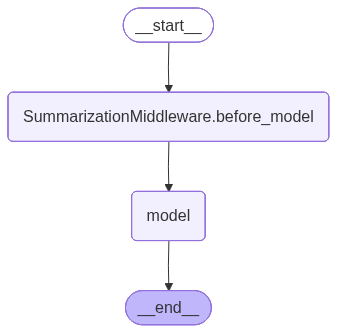

In [23]:
# Step 1: Model object
model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

# Step 2: Create agent
agent = create_agent(
    model=model,
    tools=[],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,   # ✅ FIXED
            trigger=("messages", 10),
            keep=("messages", 4)
        )
    ]
)
agent


In [24]:
config = {"configurable":{"thread_id":"test1"}}

In [25]:
# Alternative test data
questions = [
  "What is 2+2?"
  "What is 10*5?",
  "What is 100/4?",
  "What is 15-7?",
  "What is 3*3?",
  "What is 4*4?",
]
for q in questions:
  response = agent.invoke({"messages":[HumanMessage(content=q)]},config)
  print(f"message;{response}")
  print(f"message;{len(response['messages'])}")

message;{'messages': [HumanMessage(content='What is 2+2?What is 10*5?', additional_kwargs={}, response_metadata={}, id='d4db233b-cfe4-4c41-b0d4-ff8b9ec39fae'), AIMessage(content='2 + 2 = 4\n\n10 * 5 = 50', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 49, 'total_tokens': 65, 'completion_time': 0.034734985, 'completion_tokens_details': None, 'prompt_time': 0.002702687, 'prompt_tokens_details': None, 'queue_time': 0.050255918, 'total_time': 0.037437672}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d4855-d5d6-7e83-8958-116515f902c7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 16, 'total_tokens': 65})]}
message;2
message;{'messages': [HumanMessage(content='What is 2+2?What is 10*5?', additional_kwargs={}, response_metadata={}, id='d4db233b-c

# Token Size

In [26]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core. tools import tool
from langchain_core.messages import HumanMessage
from langgraph. checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
  """Search hotels - returns long response to use more tokens."""
  return f"""Hotels in {city}:
  1. Grand Hotel - 5 star, $350/night, spa, pool, gym
  2. City Inn - 4 star, $180/night, business center
  3. Budget Stay - 3 star, $75/night, free wifi'"""
  
agent = create_agent(
  model= model,
  tools=[search_hotels],
  checkpointer=InMemorySaver(),
  middleware=[SummarizationMiddleware(
    model = model,
    trigger=("tokens",550),
    keep=("tokens",200)
  )]  
)  

config = {"configurable" : {"thread_id":"test1"}}

# Token counter (approximate)
def count_tokens (messages) :
  total_chars = sum(len(str(m.content)) for m in messages)
  return total_chars // 4 # 4 chars = 1 token

In [27]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
  response = agent. invoke(
    {"messages": [HumanMessage(content=f"Find hotels in {city}") ]},
    config=config
  )
  tokens = count_tokens (response["messages"] )
  print(f"{city}: ~{tokens} tokens, {len(response['messages']) } messages")
  print(f"{(response['messages'])}")

Paris: ~267 tokens, 10 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='6ec05618-8c6e-4136-bde2-f166c59367d9'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'gjeks4fba', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 226, 'total_tokens': 241, 'completion_time': 0.035825015, 'completion_tokens_details': None, 'prompt_time': 0.058477897, 'prompt_tokens_details': None, 'queue_time': 0.27760077, 'total_time': 0.094302912}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_e65acd3773', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d4856-0e3b-7192-9683-074a630abc3d-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'gjeks4fba', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metada

# Human In Loop

In [54]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage
from langgraph.types import Command

def read_email_tool(email_id: str) -> str:
  """Mock function to read an email by its ID."""
  return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Use this tool to send an email. Always use this when user asks to send email."""
    return f"Email sent to {recipient} with subject '{subject}'"

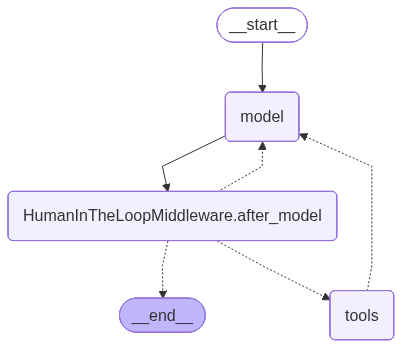

In [61]:
agent = create_agent(
    model=model,
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    system_prompt="""
You are a STRICT tool-calling agent.

RULES:
- You MUST ALWAYS call a tool if user asks to send or read email
- NEVER respond with plain text
- ALWAYS return a tool call
- If sending email → call send_email_tool
""",
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"]
                },
                "read_email_tool": False,
            }
        )
    ]
)
agent

In [62]:
# Config
config = {"configurable": {"thread_id": "test-approve"}}

# Step 1: Trigger request
result = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="Send email to john@test.com with subject 'Hello' and body 'How are you?'"
            )
        ]
    },
    config=config
)

# DEBUG (IMPORTANT)
print("Initial result:", result)

# Step 2: Handle interrupt
if "_interrupt_" in result:
    print("Interrupt detected → Approving...")

    command = Command(
        resume={
            "decision": {"type": "approve"}
        }
    )

    result = agent.invoke(command, config=config)

# Step 3: Final output
print("Messages:", result["messages"])

Initial result: {'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='0cd84895-f929-41e4-952e-747a1e77bd53'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'z8as0jma4', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 382, 'total_tokens': 414, 'completion_time': 0.054992881, 'completion_tokens_details': None, 'prompt_time': 0.051242198, 'prompt_tokens_details': None, 'queue_time': 0.072358951, 'total_time': 0.106235079}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d486b-f42e-7622-b39c-1505f803c17f-0', tool_calls=[{'name': 'send_email_tool